# Phase 2 — Factor Construction

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

## 1. Setup & Data Preparation

In [85]:
daily_returns  = pd.read_csv("../data/daily_returns.csv",  index_col="Date", parse_dates=True)
monthly_returns = pd.read_csv("../data/monthly_returns.csv", index_col="Date", parse_dates=True)

print(f"Daily returns:   {daily_returns.shape}")
print(f"Monthly returns: {monthly_returns.shape}")
monthly_returns.head()

Daily returns:   (1330, 15)
Monthly returns: (63, 15)


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2021-02-28,0.033557,-0.011696,0.000000,0.367480,NaN,-0.044944,0.005155,0.051383,0.316151,-0.045872,-0.069388,0.154929,0.045872,0.101449,0.101449
2021-03-31,0.006493,0.005917,-0.036232,0.127230,NaN,0.000000,-0.005128,0.011278,0.083551,-0.021635,0.013158,0.101626,0.149123,0.177632,-0.052632
2021-04-30,0.014194,0.082353,0.315790,0.149789,NaN,0.138824,0.108247,0.219331,0.004819,0.021264,0.085050,0.188192,0.133588,0.268156,0.027778
2021-05-31,0.027990,0.076087,0.217143,-0.034404,NaN,-0.053719,-0.009302,0.184076,-0.009918,0.047030,0.008081,-0.008696,-0.063973,0.145374,0.500000
2021-06-30,0.014851,0.015152,0.071286,0.045131,NaN,0.085153,0.065416,0.079823,0.009877,-0.018913,-0.002004,0.009190,0.056219,-0.086538,-0.072072


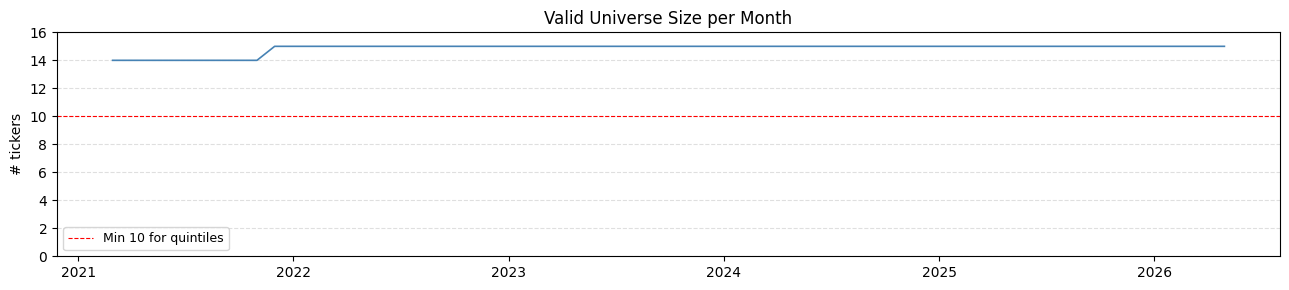

Min universe size: 14 (month: 2021-02-28)
Months with <10 tickers: 0


In [86]:
# Valid universe mask: True if ticker has a return that month
universe_mask = monthly_returns.notna()

# Universe size over time
universe_size = universe_mask.sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(universe_size.index, universe_size.values, color="steelblue", linewidth=1.2)
ax.axhline(10, color="red", linestyle="--", linewidth=0.8, label="Min 10 for quintiles")
ax.set_title("Valid Universe Size per Month", fontsize=12)
ax.set_ylabel("# tickers")
ax.set_ylim(0, 16)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Min universe size: {universe_size.min()} (month: {universe_size.idxmin().date()})")
print(f"Months with <10 tickers: {(universe_size < 10).sum()}")

## 2. Momentum Factor

### 2a. Signal Construction

In [87]:
# Standard momentum: cumulative return over lookback, skipping most recent month
# shift(1) skips lag-0 (current month), rolling computes over prior N months
mom_1 = monthly_returns.shift(1)                                                          # 1-month (no skip)
mom_3 = monthly_returns.shift(1).rolling(3).apply(lambda x: (1 + x).prod() - 1)          # 3-month
mom_6 = monthly_returns.shift(1).rolling(6).apply(lambda x: (1 + x).prod() - 1)          # 6-month

print("Non-NaN counts per signal:")
print(f"  mom_1: {mom_1.notna().sum().sum()}")
print(f"  mom_3: {mom_3.notna().sum().sum()}")
print(f"  mom_6: {mom_6.notna().sum().sum()}")
mom_3.tail(3)

Non-NaN counts per signal:
  mom_1: 921
  mom_3: 891
  mom_6: 846


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2026-02-28,0.066747,0.205212,-0.029885,0.123037,0.050357,0.154206,0.031332,0.086124,0.123404,0.078759,0.091603,0.127622,0.138675,0.098655,-0.203390
2026-03-31,-0.011142,0.178914,-0.039039,0.189979,0.058019,0.000000,0.036554,0.099398,0.217204,0.053140,0.041979,0.016129,0.063191,-0.008969,-0.040000
2026-04-30,-0.157609,0.026163,-0.096386,0.056738,0.076087,0.000000,0.031250,-0.070796,0.154639,0.007075,-0.006993,-0.134185,-0.161850,-0.220779,0.033708


### 2b & 2c. Cross-Sectional Ranking & Quintile Assignment

In [88]:
def cross_sectional_rank(signal_df, mask_df):
    """Percentile rank each ticker within the valid universe at each month-end."""
    ranks = pd.DataFrame(index=signal_df.index, columns=signal_df.columns, dtype=float)
    for date in signal_df.index:
        row   = signal_df.loc[date]
        valid = mask_df.loc[date]
        if valid.sum() < 2:
            continue
        ranks.loc[date, valid] = row[valid].rank(pct=True).values
    return ranks


def assign_quintiles(rank_df):
    """Convert percentile ranks to quintiles Q1–Q5."""
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    result = rank_df.apply(
        lambda col: pd.cut(col, bins=bins, labels=[1, 2, 3, 4, 5], include_lowest=True)
    )
    return result.astype(float)

# Apply to all three momentum windows
mom_rank_1 = cross_sectional_rank(mom_1, universe_mask)
mom_rank_3 = cross_sectional_rank(mom_3, universe_mask)
mom_rank_6 = cross_sectional_rank(mom_6, universe_mask)

mom_q_1 = assign_quintiles(mom_rank_1)
mom_q_3 = assign_quintiles(mom_rank_3)
mom_q_6 = assign_quintiles(mom_rank_6)

print("Momentum 3-month quintile assignments (last 3 months):")
mom_q_3.tail(3)

Momentum 3-month quintile assignments (last 3 months):


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2026-02-28,2.0,5.0,1.0,4.0,2.0,5.0,1.0,3.0,4.0,2.0,3.0,4.0,5.0,3.0,1.0
2026-03-31,1.0,5.0,1.0,5.0,4.0,2.0,3.0,4.0,5.0,3.0,3.0,2.0,4.0,2.0,1.0
2026-04-30,1.0,4.0,2.0,5.0,5.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0


### 2d. Signal Diagnostics

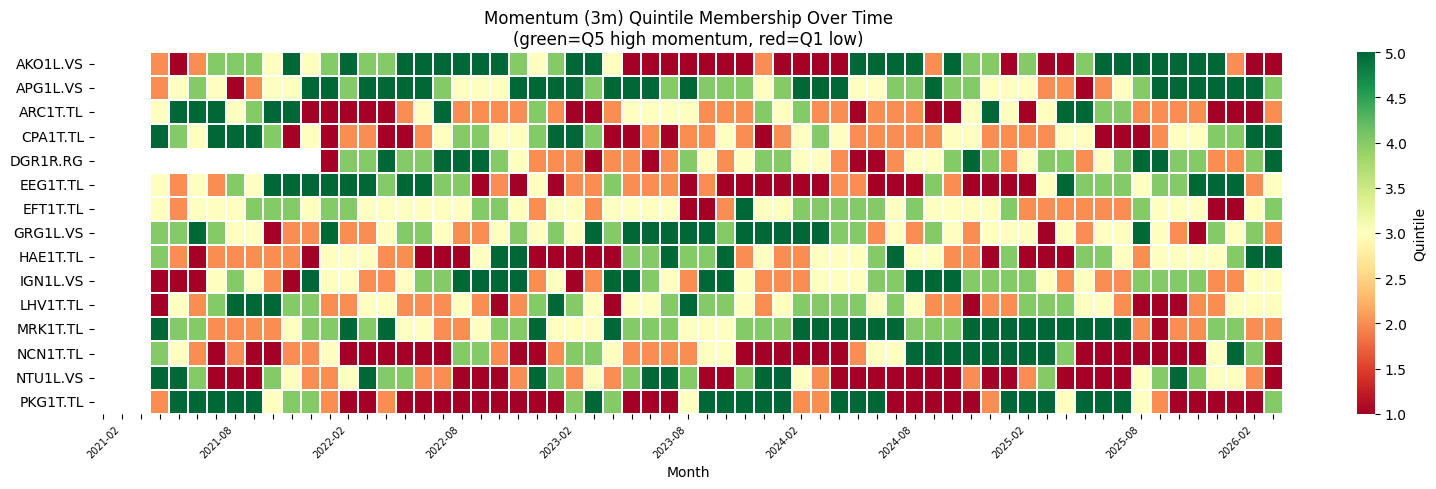

In [89]:
# Heatmap of quintile membership over time — 3-month momentum
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    mom_q_3.T.astype(float), ax=ax, cmap="RdYlGn",
    vmin=1, vmax=5, linewidths=0.3, cbar_kws={"label": "Quintile"}
)
ax.set_title("Momentum (3m) Quintile Membership Over Time\n(green=Q5 high momentum, red=Q1 low)", fontsize=12)
ax.set_xlabel("Month")
ax.set_xticklabels(
    [d.strftime("%Y-%m") if i % 6 == 0 else "" for i, d in enumerate(mom_q_3.index)],
    rotation=45, fontsize=7
)
plt.tight_layout()
plt.show()

In [90]:
# Monthly turnover: fraction of tickers that change quintile vs prior month
def monthly_turnover(quintile_df):
    changed = (quintile_df.diff().abs() > 0).sum(axis=1)
    total   = quintile_df.notna().sum(axis=1)
    return (changed / total).replace([np.inf, -np.inf], np.nan)

to_1 = monthly_turnover(mom_q_1)
to_3 = monthly_turnover(mom_q_3)
to_6 = monthly_turnover(mom_q_6)

print("Average monthly quintile turnover:")
print(f"  mom_1: {to_1.mean():.1%}")
print(f"  mom_3: {to_3.mean():.1%}")
print(f"  mom_6: {to_6.mean():.1%}")

Average monthly quintile turnover:
  mom_1: 75.9%
  mom_3: 53.7%
  mom_6: 44.3%


## 3. Mean Reversion Factor

### 3a. Signal Construction

In [91]:
# Reversal signal: negate last month's return
# High score = stock that fell last month = mean reversion long candidate
rev_1 = -monthly_returns.shift(1)
rev_3 = -monthly_returns.shift(1).rolling(3).apply(lambda x: (1 + x).prod() - 1)

print(f"rev_1 non-NaN: {rev_1.notna().sum().sum()}")
print(f"rev_3 non-NaN: {rev_3.notna().sum().sum()}")
rev_1.tail(3)

rev_1 non-NaN: 921
rev_3 non-NaN: 891


,AKO1L.VS,APG1L.VS,ARC1T.TL,CPA1T.TL,DGR1R.RG,EEG1T.TL,EFT1T.TL,GRG1L.VS,HAE1T.TL,IGN1L.VS,LHV1T.TL,MRK1T.TL,NCN1T.TL,NTU1L.VS,PKG1T.TL
Date,,,,,,,,,,,,,,,
2026-02-28,0.005435,-0.075581,0.021084,-0.014184,-0.024845,-0.004065,-0.028646,-0.004425,-0.088660,-0.066038,-0.000000,-0.030351,-0.067919,-0.060606,-0.056180
2026-03-31,0.030055,0.002703,0.015385,-0.062937,-0.015152,-0.004049,-0.005063,0.035242,-0.071970,0.035398,0.027972,0.120930,0.089310,0.097959,-0.021277
2026-04-30,0.126761,0.043360,0.062500,0.019737,-0.034328,0.008065,0.002519,0.041096,0.010601,0.020642,-0.021583,0.044092,0.138187,0.185520,0.041667


### 3b & 3c. Ranking, Quintiles & Diagnostics

In [92]:
rev_rank_1 = cross_sectional_rank(rev_1, universe_mask)
rev_rank_3 = cross_sectional_rank(rev_3, universe_mask)

rev_q_1 = assign_quintiles(rev_rank_1)
rev_q_3 = assign_quintiles(rev_rank_3)

# Turnover
rev_to_1 = monthly_turnover(rev_q_1)
rev_to_3 = monthly_turnover(rev_q_3)
print("Average monthly quintile turnover:")
print(f"  rev_1: {rev_to_1.mean():.1%}")
print(f"  rev_3: {rev_to_3.mean():.1%}")

Average monthly quintile turnover:
  rev_1: 74.6%
  rev_3: 53.9%


In [93]:
# Are momentum and reversal quintiles anti-correlated?
# Compare mom_1 rank vs rev_1 rank — should be near -1.0
overlap_corrs = []
for date in mom_rank_1.index:
    m = mom_rank_1.loc[date].dropna()
    r = rev_rank_1.loc[date].dropna()
    common = m.index.intersection(r.index)
    if len(common) >= 4:
        c, _ = spearmanr(m[common], r[common])
        overlap_corrs.append(c)

print(f"Mean Spearman corr(mom_1_rank, rev_1_rank): {np.mean(overlap_corrs):.3f}")
print("(Expected ≈ -1.0 since rev_1 = -mom_1)")

Mean Spearman corr(mom_1_rank, rev_1_rank): -1.000
(Expected ≈ -1.0 since rev_1 = -mom_1)


## 4. Volatility Factor

### 4a. Signal Construction

In [ ]:
# 1-month (21-day) realised vol, annualised — snapshot at each month-end
# min_periods=14: compute vol if at least 14 of 21 days are present (handles gaps)
vol_1m_daily = daily_returns.rolling(21, min_periods=14).std() * np.sqrt(252)
vol_signal_1m = vol_1m_daily.resample("ME").last()

# 3-month (63-day) realised vol — smoother, reduces vol-of-vol noise
# min_periods=42: require at least 2/3 of the window
vol_3m_daily = daily_returns.rolling(63, min_periods=42).std() * np.sqrt(252)
vol_signal_3m = vol_3m_daily.resample("ME").last()

# Align index to monthly_returns
vol_signal_1m = vol_signal_1m.reindex(monthly_returns.index, method="nearest", tolerance=pd.Timedelta("5D"))
vol_signal_3m = vol_signal_3m.reindex(monthly_returns.index, method="nearest", tolerance=pd.Timedelta("5D"))

print(f"NaN in vol_signal_3m: {vol_signal_3m.isna().sum().sum()}  (monthly_returns: {monthly_returns.isna().sum().sum()})")
print("1m vol signal (last 3 months):")
vol_signal_1m.tail(3).round(3)

### 4b & 4c. Ranking, Quintiles & Stability Check

In [95]:
# Use universe_mask from monthly_returns for consistency
vol_mask = vol_signal_3m.notna() & universe_mask.reindex(vol_signal_3m.index, fill_value=False)

vol_rank_1m = cross_sectional_rank(vol_signal_1m, vol_mask)
vol_rank_3m = cross_sectional_rank(vol_signal_3m, vol_mask)

vol_q_1m = assign_quintiles(vol_rank_1m)
vol_q_3m = assign_quintiles(vol_rank_3m)

# Turnover comparison — does 3m smoothing help?
vol_to_1m = monthly_turnover(vol_q_1m)
vol_to_3m = monthly_turnover(vol_q_3m)
print("Volatility factor quintile turnover:")
print(f"  1-month vol: {vol_to_1m.mean():.1%}")
print(f"  3-month vol: {vol_to_3m.mean():.1%}")

Volatility factor quintile turnover:
  1-month vol: 44.0%
  3-month vol: 28.7%


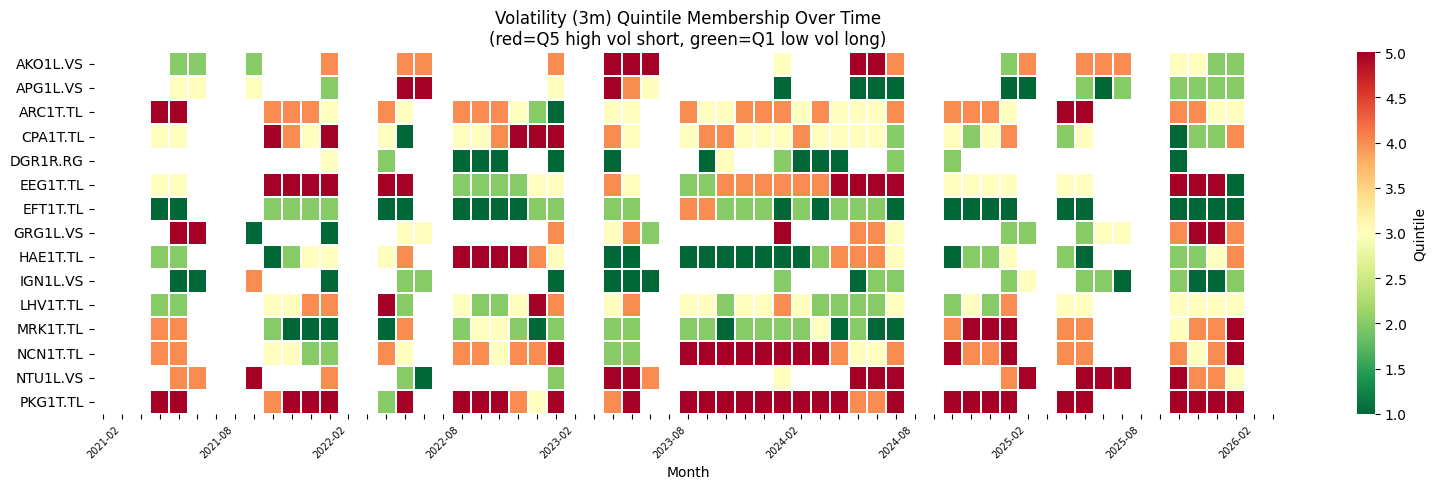

In [96]:
# Quintile persistence heatmap — 3-month vol
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    vol_q_3m.T.astype(float), ax=ax, cmap="RdYlGn_r",
    vmin=1, vmax=5, linewidths=0.3, cbar_kws={"label": "Quintile"}
)
ax.set_title("Volatility (3m) Quintile Membership Over Time\n(red=Q5 high vol short, green=Q1 low vol long)", fontsize=12)
ax.set_xlabel("Month")
ax.set_xticklabels(
    [d.strftime("%Y-%m") if i % 6 == 0 else "" for i, d in enumerate(vol_q_3m.index)],
    rotation=45, fontsize=7
)
plt.tight_layout()
plt.show()

## 5. Factor Correlation & Orthogonality

### 5a. Signal-Level Spearman Correlations

In [97]:
# For each month, compute Spearman corr between each pair of factor ranks
pairs = {
    "mom_3 vs rev_1": (mom_rank_3, rev_rank_1),
    "mom_3 vs vol_3m": (mom_rank_3, vol_rank_3m),
    "rev_1 vs vol_3m": (rev_rank_1, vol_rank_3m),
}

corr_results = {}
for label, (ra, rb) in pairs.items():
    monthly_corrs = []
    for date in ra.index:
        a = ra.loc[date].dropna()
        b = rb.loc[date].dropna()
        common = a.index.intersection(b.index)
        if len(common) >= 4:
            c, _ = spearmanr(a[common], b[common])
            monthly_corrs.append(c)
    corr_results[label] = np.mean(monthly_corrs)

print("Average Spearman rank correlations between factor signals:")
for k, v in corr_results.items():
    flag = " ← REDUNDANT" if abs(v) > 0.7 else ""
    print(f"  {k:<25} {v:+.3f}{flag}")

Average Spearman rank correlations between factor signals:
  mom_3 vs rev_1            -0.551
  mom_3 vs vol_3m           -0.015
  rev_1 vs vol_3m           +0.013


### 5b. Quintile Overlap Matrix

In [98]:
# For each pair: what % of months does a ticker land in Q5 of both factors simultaneously?
def q5_overlap(qa, qb):
    both_q5 = ((qa == 5) & (qb == 5)).sum().sum()
    total_q5_a = (qa == 5).sum().sum()
    return both_q5 / total_q5_a if total_q5_a > 0 else np.nan

overlap = pd.DataFrame(index=["mom_3", "rev_1", "vol_3m"], columns=["mom_3", "rev_1", "vol_3m"])
factor_qs = {"mom_3": mom_q_3, "rev_1": rev_q_1, "vol_3m": vol_q_3m}

for a in overlap.index:
    for b in overlap.columns:
        overlap.loc[a, b] = round(q5_overlap(factor_qs[a], factor_qs[b]), 3)

print("Q5 overlap matrix (fraction of Q5-a that is also Q5-b):")
print(overlap.to_string())

Q5 overlap matrix (fraction of Q5-a that is also Q5-b):
        mom_3  rev_1 vol_3m
mom_3     1.0  0.056    0.2
rev_1   0.053    1.0  0.149
vol_3m  0.364  0.283    1.0


## 6. Factor Scores — Final Output

In [99]:
# Final factor score DataFrames: percentile rank (0-1), NaN where not in universe
# Use 3-month momentum, 1-month reversal, 3-month vol as primary signals
factor_momentum  = mom_rank_3.copy()
factor_reversion = rev_rank_1.copy()
factor_volatility = vol_rank_3m.copy()

print("Factor shapes:")
print(f"  factor_momentum:  {factor_momentum.shape}")
print(f"  factor_reversion: {factor_reversion.shape}")
print(f"  factor_volatility:{factor_volatility.shape}")

print("\nCoverage (non-NaN %) per factor:")
print(f"  momentum:   {factor_momentum.notna().mean().mean():.1%}")
print(f"  reversion:  {factor_reversion.notna().mean().mean():.1%}")
print(f"  volatility: {factor_volatility.notna().mean().mean():.1%}")

Factor shapes:
  factor_momentum:  (63, 15)
  factor_reversion: (63, 15)
  factor_volatility:(63, 15)

Coverage (non-NaN %) per factor:
  momentum:   94.3%
  reversion:  97.5%
  volatility: 50.1%


In [100]:
factor_momentum.to_csv("../data/factor_momentum.csv")
factor_reversion.to_csv("../data/factor_reversion.csv")
factor_volatility.to_csv("../data/factor_volatility.csv")
print("Saved factor_momentum.csv, factor_reversion.csv, factor_volatility.csv")

Saved factor_momentum.csv, factor_reversion.csv, factor_volatility.csv


## 7. Key Questions — Summary

In [101]:
print("=" * 55)
print("PHASE 2 SUMMARY")
print("=" * 55)

print("\n1. Momentum window turnover (lower = more stable):")
print(f"   1m: {to_1.mean():.1%}  |  3m: {to_3.mean():.1%}  |  6m: {to_6.mean():.1%}")

print("\n2. Momentum vs reversal correlation:")
print(f"   {corr_results['mom_3 vs rev_1']:+.3f}  (< -0.7 = redundant, use one only)")

print("\n3. Vol factor turnover (1m vs 3m smoothing):")
print(f"   1m vol: {vol_to_1m.mean():.1%}  |  3m vol: {vol_to_3m.mean():.1%}")

print("\n4. Valid universe size:")
print(f"   Min: {universe_size.min()}  |  Mean: {universe_size.mean():.1f}  |  Months < 10: {(universe_size < 10).sum()}")

print("\n5. Factor orthogonality:")
for k, v in corr_results.items():
    print(f"   {k}: {v:+.3f}")

PHASE 2 SUMMARY

1. Momentum window turnover (lower = more stable):
   1m: 75.9%  |  3m: 53.7%  |  6m: 44.3%

2. Momentum vs reversal correlation:
   -0.551  (< -0.7 = redundant, use one only)

3. Vol factor turnover (1m vs 3m smoothing):
   1m vol: 44.0%  |  3m vol: 28.7%

4. Valid universe size:
   Min: 14  |  Mean: 14.9  |  Months < 10: 0

5. Factor orthogonality:
   mom_3 vs rev_1: -0.551
   mom_3 vs vol_3m: -0.015
   rev_1 vs vol_3m: +0.013
